In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [61]:
# read csv file
df = pd.read_csv("/eos/user/t/tcostaes/traccc_outputs/profiling/1t_10ev_1rep/quick_checks/mldev02_full.csv")

In [62]:
# assign event id based on ccl_kernel 
# here should output 15 indexes - 5 cold runs + 10 processed events
df[df["Function Name"]=="ccl_kernel"].index

Index([   0,  263,  526,  805, 1046, 1305, 1584, 1855, 2114, 2367, 2638, 2917,
       3188, 3459, 3756],
      dtype='int64')

In [63]:
print("Number of kernel launches: ", len(df))
print("Number of unique functions: ", len(df["Function Name"].unique()))
df["Function Name"].value_counts().head(28)

Number of kernel launches:  3997
Number of unique functions:  28


Function Name
DeviceRadixSortOnesweepKernel               732
DeviceRadixSortSingleTileKernel             432
apply_interaction                           360
find_tracks                                 360
propagate_to_next_surface                   345
fill_finding_propagation_sort_keys          345
remove_duplicates                           270
fill_finding_duplicate_removal_sort_keys    270
DeviceRadixSortExclusiveSumKernel           183
DeviceRadixSortHistogramKernel              183
DeviceMergeSortPartitionKernel              131
DeviceMergeSortMergeKernel                  131
static_kernel                                30
count_triplets                               15
count_doublets                               15
populate_grid                                15
count_grid_capacities                        15
form_spacepoints                             15
fill_sorted_measurements                     15
DeviceMergeSortBlockSortKernel               15
ccl_kernel                

In [64]:
#split dataframe into events 
event_starts = df[df["Function Name"]=="ccl_kernel"].index.tolist()
events = []
for i, start in enumerate(event_starts):
    if i < len(event_starts)-1:
        event = df.iloc[start:event_starts[i+1]]
    else:
        event = df.iloc[start:]
    events.append(event)
print(len(events))

15


In [65]:
# count function calls per event 
event_function_counts = []

for i, event in enumerate(events):
    counts = event["Function Name"].value_counts()
    counts.name = f"Event {i}"
    event_function_counts.append(counts)

# Functions as rows, events as columns
event_function_counts = pd.DataFrame(event_function_counts).fillna(0).astype(int).T

event_function_counts.index.name = "Function Name"


display(event_function_counts)

,Event 0,Event 1,Event 2,Event 3,Event 4,Event 5,Event 6,Event 7,Event 8,Event 9,Event 10,Event 11,Event 12,Event 13,Event 14
Function Name,,,,,,,,,,,,,,,
DeviceRadixSortOnesweepKernel,52,52,52,36,44,52,52,44,44,52,52,52,52,60,36
DeviceRadixSortSingleTileKernel,26,26,30,30,30,30,28,30,28,28,30,28,28,30,30
apply_interaction,23,23,25,23,24,25,24,24,23,24,25,24,24,26,23
find_tracks,23,23,25,23,24,25,24,24,23,24,25,24,24,26,23
propagate_to_next_surface,22,22,24,22,23,24,23,23,22,23,24,23,23,25,22
fill_finding_propagation_sort_keys,22,22,24,22,23,24,23,23,22,23,24,23,23,25,22
remove_duplicates,17,17,19,17,18,19,18,18,17,18,19,18,18,20,17
fill_finding_duplicate_removal_sort_keys,17,17,19,17,18,19,18,18,17,18,19,18,18,20,17
DeviceRadixSortExclusiveSumKernel,13,13,13,9,11,13,13,11,11,13,13,13,13,15,9


In [66]:
# calculate GPU time per event (5 cold run + 10 processed) * 1 rep
event_times = []
for i, event in enumerate(events):
    total = event["Duration [ms]"].sum()
    event_times.append(total)
print(event_times)
print(len(event_times))

[np.float64(79.67999999999998), np.float64(80.21), np.float64(78.86999999999999), np.float64(54.929999999999986), np.float64(62.54999999999999), np.float64(80.64999999999998), np.float64(80.01999999999998), np.float64(60.93999999999998), np.float64(69.44999999999999), np.float64(72.80999999999999), np.float64(81.98), np.float64(78.87999999999998), np.float64(72.80999999999997), np.float64(89.37), np.float64(54.02999999999999)]
15


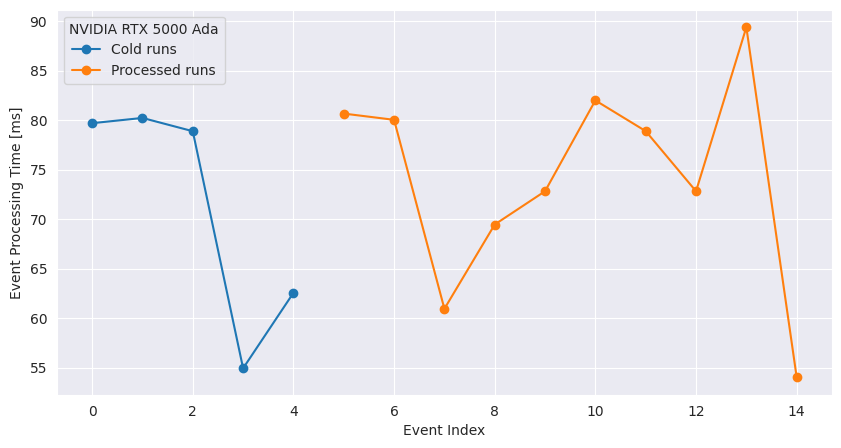

In [67]:
# plot event processing time vs event index
cold_runs = event_times[:5]
processed_runs = event_times[5:]

plt.figure(figsize=(10, 5))

plt.plot(range(5), cold_runs, marker='o', label="Cold runs")
plt.plot(range(5, len(event_times)), processed_runs, marker='o', label="Processed runs")

plt.xlabel("Event Index")
plt.ylabel("Event Processing Time [ms]")
plt.legend(title="NVIDIA RTX 5000 Ada")
plt.grid(True)

plt.show()